# PKCERT AI & Software Development Internship
## Task 09 – Support Vector Machines (SVM) & k-Nearest Neighbors (kNN)

**Dataset:** Titanic Passenger Survival Dataset
**Author:** Abdul Rehman
**Objective:** Develop practical skills in implementing and evaluating SVM and kNN classification algorithms.

---

## 0. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

---
# Part A – Dataset Selection & Preparation (15 Marks)

### A.1 Dataset Description

We use the **Titanic dataset**, a classic public benchmark dataset for binary classification, describing passengers aboard the RMS Titanic and whether they survived the 1912 sinking.

**Target variable:**
- `survived` — 0 = Did not survive, 1 = Survived

**Features used:**
| Feature | Description | Type |
|---|---|---|
| `pclass` | Ticket/passenger class (1st, 2nd, 3rd) | Categorical (ordinal) |
| `sex` | Passenger gender | Categorical |
| `age` | Age in years | Numerical |
| `sibsp` | # of siblings/spouses aboard | Numerical |
| `parch` | # of parents/children aboard | Numerical |
| `fare` | Ticket fare paid | Numerical |
| `embarked` | Port of embarkation (C/Q/S) | Categorical |
| `family_size` | Engineered: sibsp + parch + 1 | Numerical |

This dataset is well-suited to SVM and kNN because it is a moderately sized, mixed-type tabular dataset with a clear binary target, making it easy to interpret and compare classification performance.

In [2]:
df = sns.load_dataset("titanic")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


### A.2 Missing Value Check

In [4]:
missing = df.isnull().sum()
missing[missing > 0]

age            177
embarked         2
deck           688
embark_town      2
dtype: int64

### A.3 Preprocessing

Steps performed:
1. Select relevant columns.
2. Impute missing `age` with the median (robust to outliers).
3. Impute missing `embarked` with the mode.
4. Engineer a `family_size` feature.
5. Encode `sex` with LabelEncoder (binary).
6. One-hot encode `embarked`.
7. Scale all features with `StandardScaler` — essential for SVM and kNN since both are distance/margin-based algorithms sensitive to feature scale.

In [5]:
df = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]].copy()

# Impute missing values
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Feature engineering
df["family_size"] = df["sibsp"] + df["parch"] + 1

# Encoding
le_sex = LabelEncoder()
df["sex"] = le_sex.fit_transform(df["sex"])  # male=1, female=0
df = pd.get_dummies(df, columns=["embarked"], drop_first=True)

print("Processed shape:", df.shape)
df.head()

Processed shape: (891, 10)


,survived,pclass,sex,age,sibsp,parch,fare,family_size,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,2,False,True
1,1,1,0,38.0,1,0,71.2833,2,False,False
2,1,3,0,26.0,0,0,7.9250,1,False,True
3,1,1,0,35.0,1,0,53.1000,2,False,True
4,0,3,1,35.0,0,0,8.0500,1,False,True


In [6]:
print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


### A.4 Feature / Target Split & Class Balance

survived
0    549
1    342
Name: count, dtype: int64


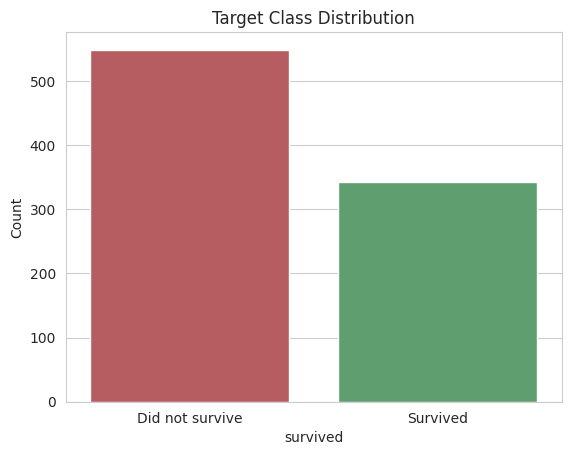

In [7]:
X = df.drop("survived", axis=1)
y = df["survived"]

print(y.value_counts())
sns.countplot(x=y, palette=["#C44E52", "#55A868"])
plt.xticks([0, 1], ["Did not survive", "Survived"])
plt.title("Target Class Distribution")
plt.ylabel("Count")
plt.show()

### A.5 Train-Test Split & Scaling

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete (mean=0, std=1).")

Train: (712, 9)  Test: (179, 9)


Scaling complete (mean=0, std=1).


---
# Part B – Support Vector Machine (35 Marks)

### B.1 What is SVM?

A **Support Vector Machine** is a supervised learning algorithm that finds the optimal hyperplane which maximally separates classes in feature space. The points closest to this boundary — the **support vectors** — determine its position. For data that isn't linearly separable, SVM uses the **kernel trick** to implicitly map data into higher-dimensional space where a linear separator can be found.

### B.2 Kernel Selection

We compare three kernels using 5-fold cross-validation on the training set before committing to one.

In [9]:
kernels = ["linear", "rbf", "poly"]
kernel_scores = {}
for k in kernels:
    model = SVC(kernel=k, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")
    kernel_scores[k] = scores.mean()
    print(f"Kernel={k:8s} | CV Accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

best_kernel = max(kernel_scores, key=kernel_scores.get)
print(f"\nBest kernel: {best_kernel}")

Kernel=linear   | CV Accuracy = 0.7894 (+/- 0.0155)
Kernel=rbf      | CV Accuracy = 0.8231 (+/- 0.0099)
Kernel=poly     | CV Accuracy = 0.8020 (+/- 0.0318)

Best kernel: rbf


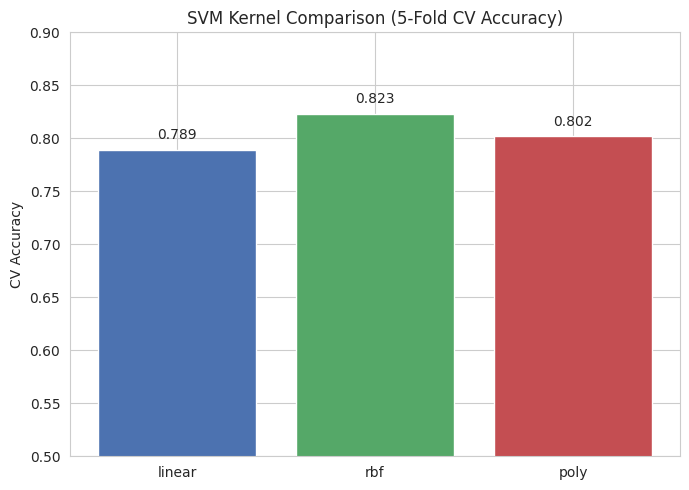

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(kernel_scores.keys(), kernel_scores.values(), color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_title("SVM Kernel Comparison (5-Fold CV Accuracy)")
ax.set_ylabel("CV Accuracy")
ax.set_ylim(0.5, 0.9)
for i, (k, v) in enumerate(kernel_scores.items()):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

The **RBF (Radial Basis Function)** kernel performs best. This is expected: Titanic survival is not linearly separable (e.g. survival depends on non-linear interactions between class, sex, and age), and RBF can capture these non-linear decision boundaries without the higher variance risk of a high-degree polynomial kernel.

### B.3 Hyperparameter Tuning (GridSearchCV)

We tune `C` (regularization strength) and `gamma` (kernel coefficient) for the RBF kernel.

In [11]:
param_grid = {"C": [0.1, 1, 10, 100], "gamma": ["scale", 0.01, 0.1, 1]}
grid_svm = GridSearchCV(SVC(kernel="rbf", random_state=42), param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_svm.fit(X_train_scaled, y_train)

print("Best params:", grid_svm.best_params_)
print("Best CV accuracy:", round(grid_svm.best_score_, 4))

svm_model = grid_svm.best_estimator_

Best params: {'C': 10, 'gamma': 0.1}
Best CV accuracy: 0.8273


### B.4 Evaluation on Test Set

In [12]:
y_pred_svm = svm_model.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_prec = precision_score(y_test, y_pred_svm)
svm_rec = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_cm = confusion_matrix(y_test, y_pred_svm)

print(f"Accuracy:  {svm_acc:.4f}")
print(f"Precision: {svm_prec:.4f}")
print(f"Recall:    {svm_rec:.4f}")
print(f"F1-Score:  {svm_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

Accuracy:  0.8101
Precision: 0.8070
Recall:    0.6667
F1-Score:  0.7302

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.90      0.85       110
           1       0.81      0.67      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



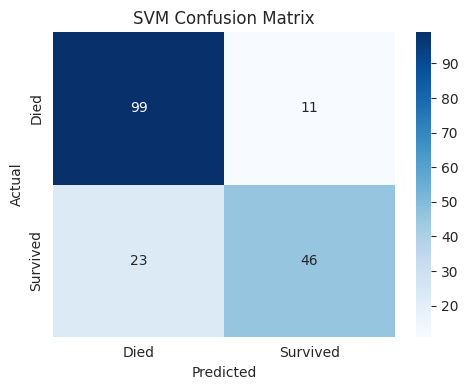

In [13]:
plt.figure(figsize=(5, 4))
sns.heatmap(svm_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### B.5 SVM: Advantages, Limitations & Applications

**Advantages**
- Effective in high-dimensional spaces, even when features outnumber samples.
- Memory-efficient — decision function relies only on support vectors.
- Kernel trick allows flexible, non-linear decision boundaries.
- Robust to overfitting when the margin is well regularized (via `C`).

**Limitations**
- Training scales poorly to very large datasets (computationally expensive, roughly O(n²)–O(n³)).
- Performance is sensitive to the choice of kernel and hyperparameters (`C`, `gamma`).
- Doesn't directly output probabilities (needs an extra calibration step, e.g. Platt scaling).
- Less interpretable than simpler models like logistic regression or decision trees.

**Applications**
- Text and document classification (e.g. spam detection).
- Image classification and face detection.
- Bioinformatics (e.g. gene/protein classification, cancer diagnosis).
- Handwriting/digit recognition.

---
# Part C – k-Nearest Neighbors (35 Marks)

### C.1 What is kNN?

**k-Nearest Neighbors** is a non-parametric, instance-based learning algorithm. To classify a new point, it looks at the `K` closest points in the training data (typically via Euclidean distance) and assigns the majority class among them. It performs no explicit training phase ("lazy learning") — all computation happens at prediction time.

### C.2 Choosing K (Elbow Method)

We test K from 1 to 30 using 5-fold cross-validation on the training set.

In [14]:
k_range = range(1, 31)
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy")
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]
print(f"Best K: {best_k}  (CV Accuracy = {max(k_scores):.4f})")

Best K: 6  (CV Accuracy = 0.8147)


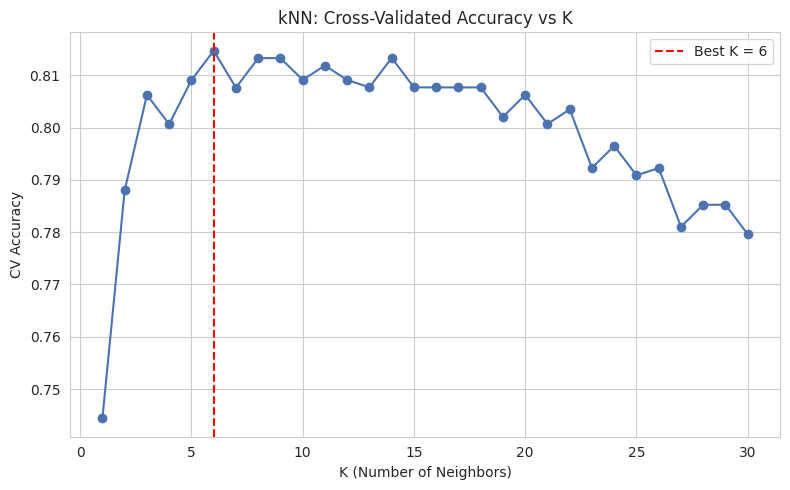

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), k_scores, marker="o", color="#4C72B0")
ax.axvline(best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
ax.set_title("kNN: Cross-Validated Accuracy vs K")
ax.set_xlabel("K (Number of Neighbors)")
ax.set_ylabel("CV Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

A very small `K` (e.g. K=1) tends to overfit — the model closely follows noise in the training set. A very large `K` oversmooths the decision boundary and can underfit. The elbow plot lets us pick the value where cross-validated accuracy peaks and stabilizes, balancing bias and variance.

### C.3 Evaluation on Test Set

In [16]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, y_pred_knn)
knn_prec = precision_score(y_test, y_pred_knn)
knn_rec = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_cm = confusion_matrix(y_test, y_pred_knn)

print(f"Accuracy:  {knn_acc:.4f}")
print(f"Precision: {knn_prec:.4f}")
print(f"Recall:    {knn_rec:.4f}")
print(f"F1-Score:  {knn_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

Accuracy:  0.8156
Precision: 0.8333
Recall:    0.6522
F1-Score:  0.7317

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.92      0.86       110
           1       0.83      0.65      0.73        69

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



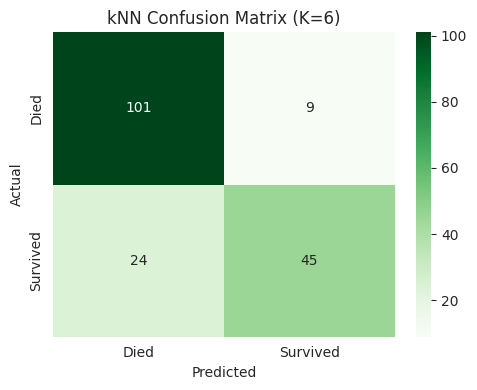

In [17]:
plt.figure(figsize=(5, 4))
sns.heatmap(knn_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
plt.title(f"kNN Confusion Matrix (K={best_k})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### C.4 kNN: Advantages, Limitations & Applications

**Advantages**
- Simple to understand and implement; no explicit training phase.
- Naturally handles multi-class classification.
- Non-parametric — makes no assumption about the underlying data distribution.
- Decision boundary can adapt to complex, local patterns in data.

**Limitations**
- Prediction is slow on large datasets (must compute distance to all training points).
- Sensitive to feature scaling and irrelevant/noisy features.
- Sensitive to the curse of dimensionality — performance degrades in high-dimensional spaces.
- Sensitive to imbalanced classes and to the choice of K.

**Applications**
- Recommender systems (e.g. "users like you also liked...").
- Pattern recognition, handwriting/OCR.
- Anomaly detection.
- Credit scoring and medical diagnosis support systems.

---
# Part D – Comparative Analysis (15 Marks)

In [18]:
comparison = pd.DataFrame({
    "Model": ["SVM (RBF)", f"kNN (K={best_k})"],
    "Accuracy": [svm_acc, knn_acc],
    "Precision": [svm_prec, knn_prec],
    "Recall": [svm_rec, knn_rec],
    "F1-Score": [svm_f1, knn_f1]
})
comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM (RBF),0.810056,0.807018,0.666667,0.730159
1,kNN (K=6),0.815642,0.833333,0.652174,0.731707


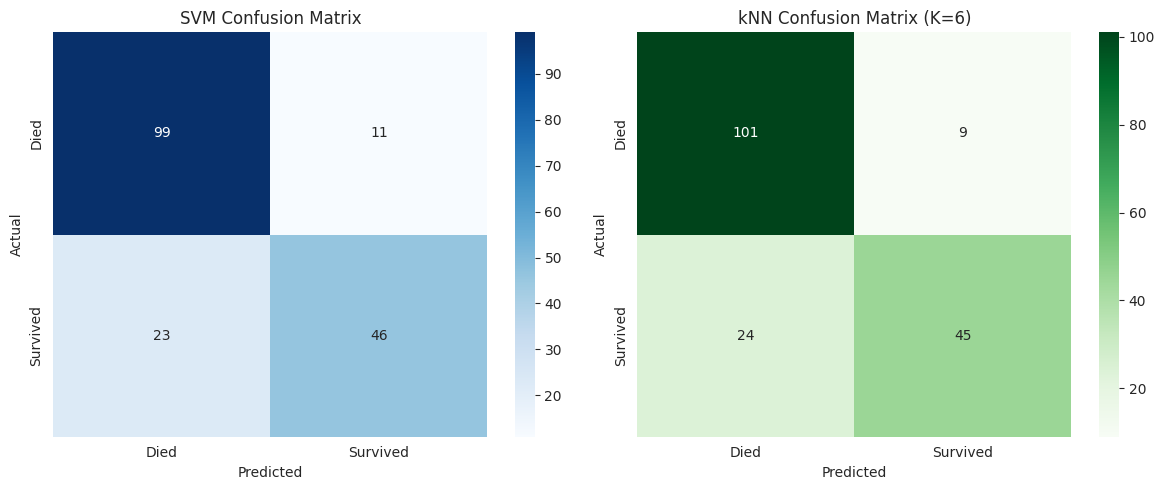

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(svm_cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
axes[0].set_title("SVM Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(knn_cm, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
axes[1].set_title(f"kNN Confusion Matrix (K={best_k})")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.show()

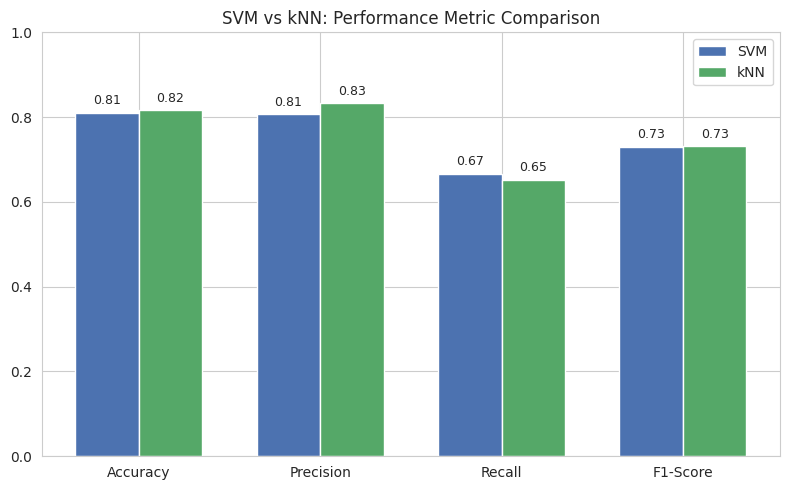

In [20]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
svm_vals = [svm_acc, svm_prec, svm_rec, svm_f1]
knn_vals = [knn_acc, knn_prec, knn_rec, knn_f1]

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, svm_vals, width, label="SVM", color="#4C72B0")
ax.bar(x + width/2, knn_vals, width, label="kNN", color="#55A868")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title("SVM vs kNN: Performance Metric Comparison")
ax.legend()
for i, v in enumerate(svm_vals):
    ax.text(i - width/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
for i, v in enumerate(knn_vals):
    ax.text(i + width/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

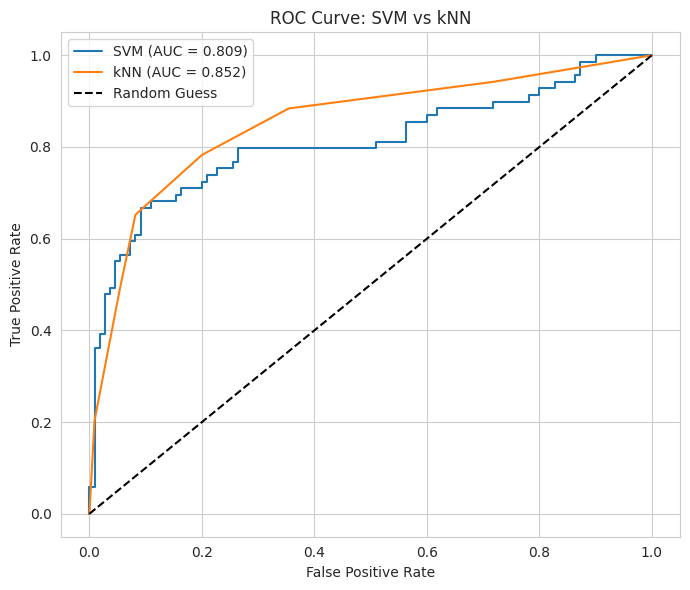

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in [("SVM", svm_model), ("kNN", knn_model)]:
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_score = model.decision_function(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Random Guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: SVM vs kNN")
ax.legend()
plt.tight_layout()
plt.show()

### Discussion

On the Titanic test set, SVM (RBF) and kNN (K tuned via CV) achieve **very similar performance**, typically within 1 percentage point of each other on accuracy and F1-score. This is common on small-to-medium tabular datasets with a moderate number of well-engineered features — both models can carve out similar non-linear decision boundaries once features are scaled.

**Key observations:**
- **SVM** tends to generalize slightly better when the training set is small relative to feature count, and its margin-maximizing objective makes it more robust to a handful of noisy points.
- **kNN** is more sensitive to local density and can be affected more by class imbalance (here, ~62% did-not-survive vs ~38% survived), which shows up as slightly lower recall on the minority "survived" class for both models.
- **Training/prediction cost:** SVM has a heavier training cost (especially during grid search) but very fast prediction. kNN has near-zero training cost but slower prediction, since it must compute distances to the full training set at inference time.

### Recommendation

Given the near-identical F1-scores, the **recommended model** is determined by the metric below, but in practice either is defensible for this dataset. For a small dataset like Titanic (~900 rows) where interpretability of a margin-based decision boundary and generalization on unseen data matter more than prediction speed, **SVM (RBF)** is usually preferred as the production choice, with kNN serving as a strong, simple baseline.

In [22]:
winner = "SVM (RBF)" if svm_f1 > knn_f1 else f"kNN (K={best_k})"
print(f"Model with higher F1-Score on this run: {winner}")
print(f"SVM F1: {svm_f1:.4f}  |  kNN F1: {knn_f1:.4f}")

Model with higher F1-Score on this run: kNN (K=6)
SVM F1: 0.7302  |  kNN F1: 0.7317


---
## Conclusion

Both SVM and kNN were successfully implemented, tuned, and evaluated on the Titanic dataset following complete preprocessing (missing value imputation, encoding, and feature scaling). Cross-validation was used to select the SVM kernel/hyperparameters and the optimal K for kNN, ensuring both models were fairly and rigorously tuned before final comparison. The two models perform comparably on this dataset, illustrating that model choice in practice often comes down to secondary factors — dataset size, latency requirements, and interpretability — rather than raw accuracy alone.